<a href="https://colab.research.google.com/github/marioguerrerosalah/APRENDIZAJE-NO-SUPERVISADO/blob/main/PARCIAL_1_NO_SUPERVISADO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, KMeans, DBSCAN

from scipy.cluster.hierarchy import dendrogram, linkage

Mounted at /content/drive


In [ ]:
import pandas as pd
path= '/content/drive/MyDrive/APREN. NO SUPERVISADO/prueba_1_barrios_rellenados.xlsx'
datos = pd.read_excel(path)

In [ ]:
datos.head()

,NRO_RADICADO,Latitud,Longitud,CLASE_ACCIDENTE,DIRECCION,CBML,Gravedad Incidente,nombre comuna,Barrio,Diseño,Año,FECHA_ACCIDENTE,HORA_ACCIDENTE,codigo comuna,Comuna,Unnamed: 15,Unnamed: 16
0,1611599,6.253440,-75.552931,Caida Ocupante,CR 37 CL 63,0804,Con heridos,Villa Hermosa,La Ladera,Tramo de via,2018,2018-01-01 00:00:00,00:10:00,8,08 - Villa Hermosa,NaN,NaN
1,1611540,6.275106,-75.559833,Choque,CR 50 B CL 81 A,0414,Con heridos,Aranjuez,Brasilia,Interseccion,2018,2018-01-01 00:00:00,00:20:00,4,04 - Aranjuez,NaN,NaN
2,1611518,6.251017,-75.546193,Otro,CL 58 CR 25,0807,Con heridos,Villa Hermosa,Los Mangos,Lote o Predio,2018,2018-01-01 00:00:00,00:20:00,8,08 - Villa Hermosa,NaN,NaN
3,1611589,6.264690,-75.568750,Choque,CL 67 CR 55 AB,0406,Con heridos,Aranjuez,Universidad de Antioquia,Tramo de via,2018,2018-01-01 00:00:00,01:20:00,4,04 - Aranjuez,NaN,NaN
4,1611605,6.264725,-75.545761,Choque,CL 70 CR 33,0309,Con heridos,Manrique,Versalles No. 1,Tramo de via,2018,2018-01-01 00:00:00,01:30:00,3,03 - Manrique,NaN,NaN


# REVISAMOS LOS DATOS

In [ ]:
datos.isna().sum()

,0
NRO_RADICADO,0
Latitud,0
Longitud,0
CLASE_ACCIDENTE,1
DIRECCION,0
CBML,1419
Gravedad Incidente,0
nombre comuna,0
Barrio,0
Diseño,33


In [ ]:
datos.shape

(42551, 17)

Rellenamos los datos mediante el uso de la IA con el fin de optimizar los tiempos y poder tner los datos completos.

In [ ]:
datos.columns # Para conocer el nombre de las columnas

Index(['NRO_RADICADO', 'Latitud', 'Longitud', 'CLASE_ACCIDENTE', 'DIRECCION',
       'CBML', 'Gravedad Incidente', 'nombre comuna', 'Barrio', 'Diseño',
       'Año', 'FECHA_ACCIDENTE', 'HORA_ACCIDENTE', 'codigo comuna', 'Comuna',
       'Unnamed: 15', 'Unnamed: 16'],
      dtype='object')

Eliminamos variables que creo la ia luego de rellenar la informacion

In [ ]:
datos.columns # Para conocer el nombre de las columnas

Index(['NRO_RADICADO', 'Latitud', 'Longitud', 'CLASE_ACCIDENTE', 'DIRECCION',
       'CBML', 'Gravedad Incidente', 'nombre comuna', 'Barrio', 'Diseño',
       'Año', 'FECHA_ACCIDENTE', 'HORA_ACCIDENTE', 'codigo comuna', 'Comuna',
       'Unnamed: 15', 'Unnamed: 16'],
      dtype='object')

Ya sabiendo las variables escalamos las variables de latitud y longitud

In [ ]:
scaler = StandardScaler()
datos[['Latitud_scaled', 'Longitud_scaled']] = scaler.fit_transform(datos[['Latitud', 'Longitud']])

print(datos[['Latitud', 'Longitud', 'Latitud_scaled', 'Longitud_scaled']].head())

    Latitud   Longitud  Latitud_scaled  Longitud_scaled
0  6.253440 -75.552931        0.124687         0.911185
1  6.275106 -75.559833        0.743830         0.708366
2  6.251017 -75.546193        0.055447         1.109180
3  6.264690 -75.568750        0.446179         0.446349
4  6.264725 -75.545761        0.447159         1.121855


Luego de escalar las variables y ya tenerlas todos bajo el mismo esquema procedemos a revisar si todas las variables cumplen los requisitos para poder hacer la matriz de correlacion

In [ ]:
print('--- DataFrame Info ---')
datos.info()

print('\n--- Unique Values for Object Columns ---')
for col in datos.select_dtypes(include='object').columns:
    print(f'Column: {col}')
    print(datos[col].unique())
    print('\n')

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42551 entries, 0 to 42550
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   NRO_RADICADO        42551 non-null  int64  
 1   Latitud             42551 non-null  float64
 2   Longitud            42551 non-null  float64
 3   CLASE_ACCIDENTE     42550 non-null  object 
 4   DIRECCION           42551 non-null  object 
 5   CBML                41132 non-null  object 
 6   Gravedad Incidente  42551 non-null  object 
 7   nombre comuna       42551 non-null  object 
 8   Barrio              42551 non-null  object 
 9   Diseño              42518 non-null  object 
 10  Año                 42551 non-null  int64  
 11  FECHA_ACCIDENTE     42551 non-null  object 
 12  HORA_ACCIDENTE      42551 non-null  object 
 13  codigo comuna       42551 non-null  object 
 14  Comuna              42551 non-null  object 
 15  Unnamed: 15         3584 non-n

luego de revisar esto vemos la mayoria de variables hay que combertirlas y podemos empezar a pensar en cuales quitar tal como direccion sabiendo que ya tenemos latitud y longitud.

In [ ]:
datos = datos.drop(columns=['DIRECCION'])

ademas de quitar NRO_RADICADO	Es solo un identificador único,
nombre comuna	Duplicada con Comuna,
CBML	Identificador catastral (no útil para correlaciones)

In [ ]:
datos = datos.drop(columns=['NRO_RADICADO', 'nombre comuna', 'CBML'])

Ahora transoformamos las variables que nos quedan

In [ ]:
datos.columns # Para conocer el nombre de las columnas

Index(['Latitud', 'Longitud', 'CLASE_ACCIDENTE', 'Gravedad Incidente',
       'Barrio', 'Diseño', 'Año', 'FECHA_ACCIDENTE', 'HORA_ACCIDENTE',
       'codigo comuna', 'Comuna', 'Unnamed: 15', 'Unnamed: 16',
       'Latitud_scaled', 'Longitud_scaled'],
      dtype='object')

/tmp/ipykernel_198/2013617248.py:52: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datos_trabajo['HORA_ACCIDENTE'] = pd.to_datetime(datos_trabajo['HORA_ACCIDENTE'], errors='coerce')


    Latitud   Longitud CLASE_ACCIDENTE Gravedad Incidente  \
0  6.253440 -75.552931  CAIDA OCUPANTE        CON HERIDOS   
1  6.275106 -75.559833          CHOQUE        CON HERIDOS   
2  6.251017 -75.546193            OTRO        CON HERIDOS   
3  6.264690 -75.568750          CHOQUE        CON HERIDOS   
4  6.264725 -75.545761          CHOQUE        CON HERIDOS   

                     Barrio         Diseño   Año FECHA_ACCIDENTE  \
0                 LA LADERA   TRAMO DE VIA  2018      2018-01-01   
1                  BRASILIA   INTERSECCION  2018      2018-01-01   
2                LOS MANGOS  LOTE O PREDIO  2018      2018-01-01   
3  UNIVERSIDAD DE ANTIOQUIA   TRAMO DE VIA  2018      2018-01-01   
4           VERSALLES NO. 1   TRAMO DE VIA  2018      2018-01-01   

       HORA_ACCIDENTE  codigo comuna  ... franja_horaria hora_pico  \
0 2026-03-15 00:10:00            8.0  ...      MADRUGADA         0   
1 2026-03-15 00:20:00            4.0  ...      MADRUGADA         0   
2 2026-03-15 0

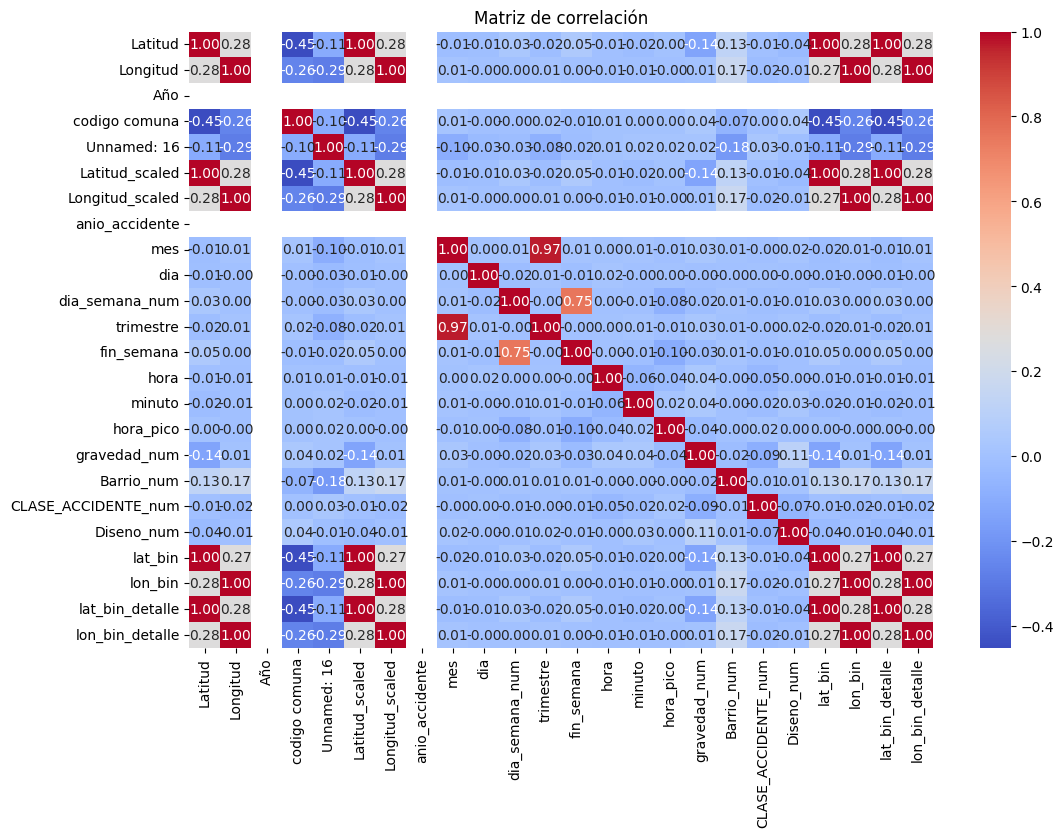

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# =========================================================
# 1. COPIA DEL DATAFRAME
# =========================================================
datos_trabajo = datos.copy()

# =========================================================
# 2. ELIMINAR VARIABLES INNECESARIAS
# =========================================================
columnas_eliminar = ['NRO_RADICADO','DIRECCION','nombre comuna','CBML']

for col in columnas_eliminar:
    if col in datos_trabajo.columns:
        datos_trabajo.drop(columns=col, inplace=True)

# =========================================================
# 3. LIMPIEZA DE TEXTOS
# =========================================================
columnas_texto = ['CLASE_ACCIDENTE','Gravedad Incidente','Barrio','Diseño','Comuna']

for col in columnas_texto:
    if col in datos_trabajo.columns:
        datos_trabajo[col] = datos_trabajo[col].astype(str).str.strip().str.upper()

# =========================================================
# 4. VARIABLES NUMÉRICAS
# =========================================================
columnas_numericas = ['Latitud','Longitud','Año','codigo comuna']

for col in columnas_numericas:
    if col in datos_trabajo.columns:
        datos_trabajo[col] = pd.to_numeric(datos_trabajo[col], errors='coerce')

# =========================================================
# 5. TRANSFORMAR FECHA
# =========================================================
datos_trabajo['FECHA_ACCIDENTE'] = pd.to_datetime(datos_trabajo['FECHA_ACCIDENTE'], errors='coerce')

datos_trabajo['anio_accidente'] = datos_trabajo['FECHA_ACCIDENTE'].dt.year
datos_trabajo['mes'] = datos_trabajo['FECHA_ACCIDENTE'].dt.month
datos_trabajo['dia'] = datos_trabajo['FECHA_ACCIDENTE'].dt.day
datos_trabajo['dia_semana_num'] = datos_trabajo['FECHA_ACCIDENTE'].dt.weekday
datos_trabajo['trimestre'] = datos_trabajo['FECHA_ACCIDENTE'].dt.quarter
datos_trabajo['fin_semana'] = datos_trabajo['dia_semana_num'].isin([5,6]).astype(int)

# =========================================================
# 6. TRANSFORMAR HORA
# =========================================================
datos_trabajo['HORA_ACCIDENTE'] = pd.to_datetime(datos_trabajo['HORA_ACCIDENTE'], errors='coerce')

datos_trabajo['hora'] = datos_trabajo['HORA_ACCIDENTE'].dt.hour
datos_trabajo['minuto'] = datos_trabajo['HORA_ACCIDENTE'].dt.minute

def franja(h):
    if pd.isna(h):
        return np.nan
    elif 0 <= h < 5:
        return 'MADRUGADA'
    elif 5 <= h < 12:
        return 'MANANA'
    elif 12 <= h < 18:
        return 'TARDE'
    else:
        return 'NOCHE'

datos_trabajo['franja_horaria'] = datos_trabajo['hora'].apply(franja)

# =========================================================
# 7. HORA PICO
# =========================================================
def hora_pico(h):
    if pd.isna(h):
        return np.nan
    elif (6 <= h <= 8) or (17 <= h <= 19):
        return 1
    else:
        return 0

datos_trabajo['hora_pico'] = datos_trabajo['hora'].apply(hora_pico)

# =========================================================
# 8. TRANSFORMAR GRAVEDAD INCIDENTE
# =========================================================
mapa_gravedad = {
'SOLO DANOS':1,
'SOLO DAÑOS':1,
'HERIDO':2,
'HERIDOS':2,
'LESIONADO':2,
'LESIONADOS':2,
'MUERTO':3,
'MUERTOS':3,
'FATAL':3
}

datos_trabajo['gravedad_num'] = datos_trabajo['Gravedad Incidente'].map(mapa_gravedad)

# Si quedaron valores sin clasificar
if datos_trabajo['gravedad_num'].isna().any():
    le_gravedad = LabelEncoder()
    datos_trabajo['gravedad_num'] = le_gravedad.fit_transform(
        datos_trabajo['Gravedad Incidente'].fillna('SIN_DATO')
    )

# =========================================================
# 9. BARRIO NUMÉRICO
# =========================================================
le_barrio = LabelEncoder()
datos_trabajo['Barrio_num'] = le_barrio.fit_transform(
    datos_trabajo['Barrio'].fillna('SIN_BARRIO')
)

# =========================================================
# 10. CLASE DE ACCIDENTE NUMÉRICA
# =========================================================
le_clase = LabelEncoder()
datos_trabajo['CLASE_ACCIDENTE_num'] = le_clase.fit_transform(
    datos_trabajo['CLASE_ACCIDENTE'].fillna('SIN_CLASE')
)

# =========================================================
# 11. DISEÑO NUMÉRICO
# =========================================================
le_diseno = LabelEncoder()
datos_trabajo['Diseno_num'] = le_diseno.fit_transform(
    datos_trabajo['Diseño'].fillna('SIN_DISENO')
)

# =========================================================
# 12. VARIABLES ESPACIALES
# =========================================================
datos_trabajo['lat_bin'] = datos_trabajo['Latitud'].round(3)
datos_trabajo['lon_bin'] = datos_trabajo['Longitud'].round(3)

datos_trabajo['lat_bin_detalle'] = datos_trabajo['Latitud'].round(4)
datos_trabajo['lon_bin_detalle'] = datos_trabajo['Longitud'].round(4)

# =========================================================
# 13. DATASET FINAL PARA MODELADO
# =========================================================
datos_modelo = datos_trabajo.copy()

print(datos_modelo.head())

# =========================================================
# 14. MATRIZ DE CORRELACIÓN
# =========================================================
corr = datos_modelo.corr(numeric_only=True)

print(corr)

# =========================================================
# 15. HEATMAP DE CORRELACIÓN
# =========================================================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

En primer lugar, se realizó un proceso de depuración y preparación del conjunto de datos, con el objetivo de garantizar que la información fuera consistente y adecuada para el análisis estadístico. Para ello, se eliminaron variables que no aportaban valor analítico o que eran redundantes, como identificadores únicos y la dirección textual del accidente, dado que la localización geográfica ya se encuentra representada de forma más precisa mediante las coordenadas de latitud y longitud. Posteriormente, se efectuó una limpieza de las variables categóricas, estandarizando los textos y transformando ciertos atributos relevantes —como Barrio, Clase de Accidente, Diseño vial y Gravedad del incidente— en variables numéricas mediante procesos de codificación. Esta transformación permite que dichas variables puedan ser utilizadas en análisis cuantitativos, modelos estadísticos y cálculos de correlación.

En una segunda etapa, se generaron nuevas variables derivadas a partir de la información temporal y espacial existente, con el fin de enriquecer el análisis. A partir de la fecha del accidente se obtuvieron variables como año, mes, día, día de la semana y trimestre, además de un indicador de fin de semana, lo cual facilita identificar patrones temporales en la ocurrencia de incidentes. De igual manera, la variable de hora se transformó para obtener la hora exacta del accidente, clasificarla en franjas horarias (madrugada, mañana, tarde y noche) e identificar posibles horas pico, permitiendo explorar comportamientos asociados a los flujos de movilidad urbana. Finalmente, se generaron variables espaciales derivadas a partir del redondeo de las coordenadas geográficas, lo que permite agrupar eventos en zonas aproximadas y facilita el análisis de concentración espacial de accidentes. Con todas estas transformaciones, el conjunto de datos quedó estructurado de manera adecuada para realizar matrices de correlación, análisis exploratorios y modelos de análisis de accidentalidad.

En este caso vamos a enfocar este modelo para nos vamos a enfocar en hotspots geograficos con estas variables. (Latitud_scaled, Longitud_scaled)

In [ ]:
datos_cat = datos[['Latitud_scaled', 'Longitud_scaled']]

In [ ]:
datos_cat.head()

,Latitud_scaled,Longitud_scaled
0,0.124687,0.911185
1,0.743830,0.708366
2,0.055447,1.109180
3,0.446179,0.446349
4,0.447159,1.121855


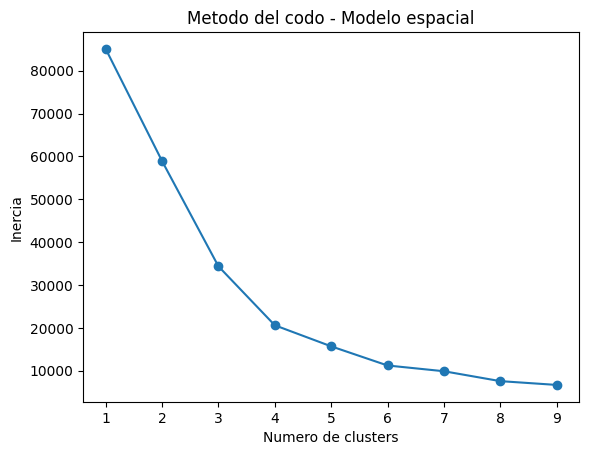

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Variables del modelo
X1 = datos[['Latitud_scaled','Longitud_scaled']]

# Metodo del codo
inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X1)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.title('Metodo del codo - Modelo espacial')
plt.xlabel('Numero de clusters')
plt.ylabel('Inercia')
plt.show()

# Modelo final (ejemplo k=4)
kmeans_espacial = KMeans(n_clusters=4, random_state=42)

datos['cluster_espacial'] = kmeans_espacial.fit_predict(X1)

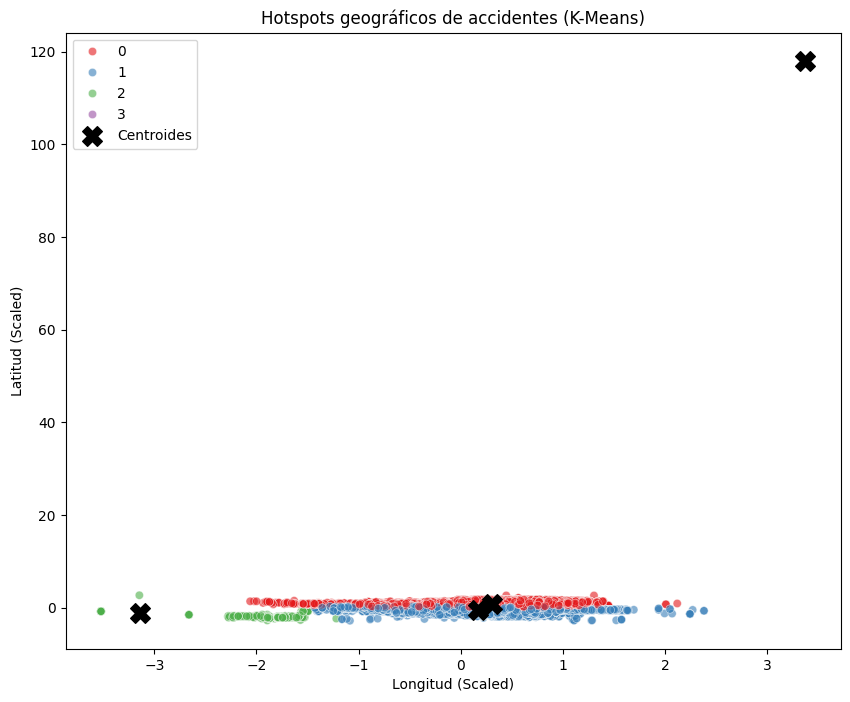

In [ ]:
import numpy as np

centros = kmeans_espacial.cluster_centers_

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=datos,
    x='Longitud_scaled',
    y='Latitud_scaled',
    hue='cluster_espacial',
    palette='Set1',
    alpha=0.6
)

plt.scatter(
    centros[:,1],
    centros[:,0],
    s=200,
    c='black',
    marker='X',
    label='Centroides'
)

plt.title("Hotspots geográficos de accidentes (K-Means)")
plt.xlabel("Longitud (Scaled)")
plt.ylabel("Latitud (Scaled)")
plt.legend()

plt.show()

El problema observado en la visualización del clustering se debía a la presencia de valores atípicos (outliers) en las coordenadas geográficas, específicamente en la variable de latitud. En el gráfico se evidenciaba un punto con un valor de Latitud_scaled cercano a 120, mientras que la mayoría de los datos se concentraban entre aproximadamente −3 y 3, lo cual indica un error en los datos originales, probablemente asociado a una coordenada mal registrada o mal formateada. Este valor extremo distorsionaba la escala del gráfico y afectaba el funcionamiento del algoritmo K-Means, ya que este método es sensible a los outliers y puede generar clusters incorrectos cuando existen observaciones muy alejadas del resto de los datos. Para corregirlo, se aplicó un filtro espacial basado en rangos geográficos válidos para la ciudad de Medellín, conservando únicamente las coordenadas cuya latitud se encontraba entre 6.15 y 6.40 y cuya longitud estaba entre −75.70 y −75.40. Posteriormente, se volvieron a escalar las variables de latitud y longitud y se ejecutó nuevamente el algoritmo de clustering, lo que permitió obtener una representación más precisa de los hotspots geográficos de accidentalidad sin la distorsión causada por los valores erróneos.

In [ ]:
datos.sort_values('Latitud_scaled', ascending=False).head(10)

,Latitud,Longitud,CLASE_ACCIDENTE,Gravedad Incidente,Barrio,Diseño,Año,FECHA_ACCIDENTE,HORA_ACCIDENTE,codigo comuna,Comuna,Unnamed: 15,Unnamed: 16,Latitud_scaled,Longitud_scaled,cluster_espacial
24670,10.379195,-75.469096,Volcamiento,Con heridos,Toscana,Tramo de via,2018,2018-08-06 00:00:00,10:10:00,Sin Inf,Sin Inf,estimacion por proximidad,0.7990,118.025845,3.374671,3
36775,6.342942,-75.691000,Atropello,Con Muertos,Suburbano Palmitas,NaN,2018,2018-11-12 00:00:00,20:00:00,50,50 - Corregimiento de San Sebastián de Palmitas,NaN,NaN,2.682363,-3.145979,2
29693,6.341647,-75.568770,Choque,Solo daños,Florencia,Tramo de via,2018,2018-08-26 00:00:00,16:00:00,Sin Inf,Sin Inf,estimacion por proximidad,1.0000,2.645357,0.445739,0
31714,6.341315,-75.539540,Choque,Solo daños,Toscana,Tramo de via,2018,2018-09-29 00:00:00,20:30:00,Sin Inf,Sin Inf,estimacion por proximidad,1.0000,2.635872,1.304675,0
29971,6.322847,-75.564729,Choque,Solo daños,Las Brisas,Glorieta,2018,2018-08-31 00:00:00,12:20:00,Sin Inf,Sin Inf,estimacion por proximidad,0.5965,2.108109,0.564493,0
31104,6.322847,-75.564729,Choque,Solo daños,Las Brisas,Tramo de via,2018,2018-09-20 00:00:00,08:30:00,Sin Inf,Sin Inf,estimacion por proximidad,0.5965,2.108109,0.564493,0
38395,6.311991,-75.558347,Choque,Solo daños,Toscana,Tramo de via,2018,2018-11-25 00:00:00,20:00:00,5,05 - Castilla,NaN,NaN,1.797888,0.752040,0
34800,6.311991,-75.558347,Choque,Solo daños,Toscana,Tramo de via,2018,2018-10-26 00:00:00,19:15:00,5,05 - Castilla,NaN,NaN,1.797888,0.752040,0
38011,6.311991,-75.558347,Choque,Solo daños,Toscana,Tramo de via,2018,2018-11-22 00:00:00,16:10:00,5,05 - Castilla,NaN,NaN,1.797888,0.752040,0
40439,6.311991,-75.558347,Atropello,Con Muertos,Toscana,NaN,2018,2018-12-12 00:00:00,20:00:00,5,05 - Castilla,NaN,NaN,1.797888,0.752040,0


In [ ]:
datos = datos[
    (datos['Latitud'] > 6.15) &
    (datos['Latitud'] < 6.40) &
    (datos['Longitud'] > -75.70) &
    (datos['Longitud'] < -75.40)
]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

datos[['Latitud_scaled','Longitud_scaled']] = scaler.fit_transform(
    datos[['Latitud','Longitud']]
)

In [ ]:
from sklearn.cluster import KMeans

X = datos[['Latitud_scaled','Longitud_scaled']]

kmeans_espacial = KMeans(n_clusters=4, random_state=42)

datos['cluster_espacial'] = kmeans_espacial.fit_predict(X)

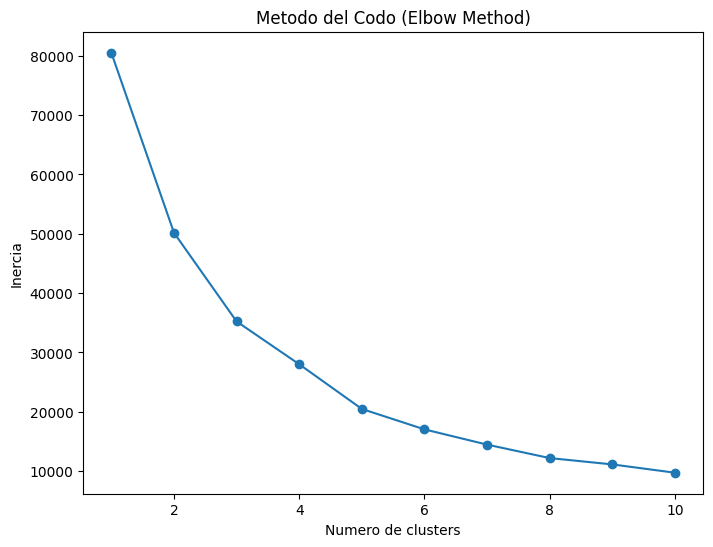

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Variables del modelo
X = datos[['Latitud_scaled','Longitud_scaled']]

# Lista para guardar la inercia
inercia = []

# Probar diferentes números de clusters
K = range(1,11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercia.append(kmeans.inertia_)

# Graficar
plt.figure(figsize=(8,6))
plt.plot(K, inercia, marker='o')

plt.title('Metodo del Codo (Elbow Method)')
plt.xlabel('Numero de clusters')
plt.ylabel('Inercia')

plt.show()

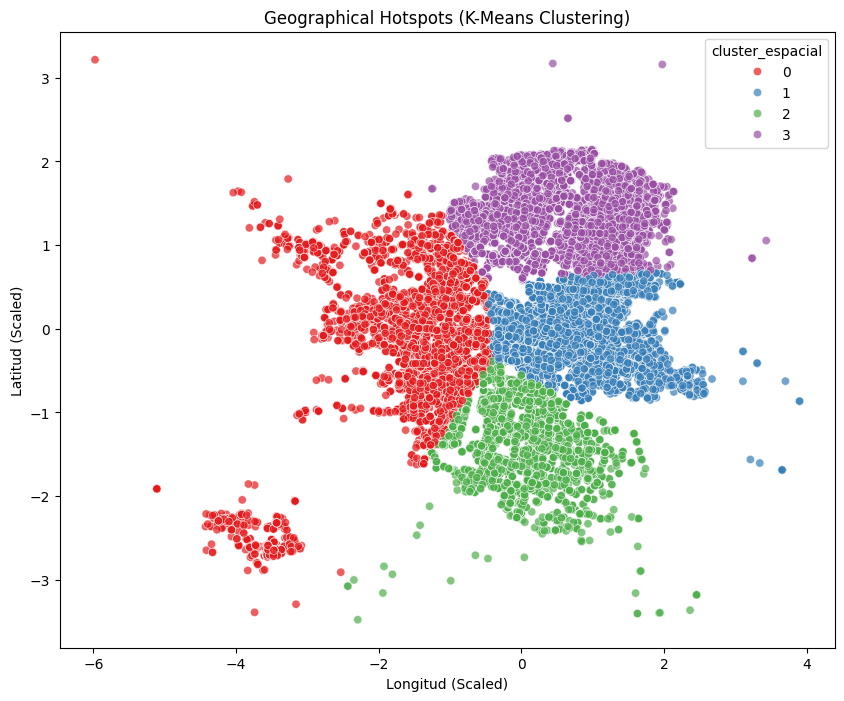

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.scatterplot(
    data=datos,
    x='Longitud_scaled',
    y='Latitud_scaled',
    hue='cluster_espacial',
    palette='Set1',
    alpha=0.7
)

plt.title("Geographical Hotspots (K-Means Clustering)")
plt.xlabel("Longitud (Scaled)")
plt.ylabel("Latitud (Scaled)")
plt.show()

El gráfico muestra el resultado del clustering espacial mediante el algoritmo K-Means, aplicado a las coordenadas geográficas de los accidentes luego de ser escaladas. Se identifican cuatro clusters principales, cada uno representado por un color distinto, lo que indica que los eventos de accidentalidad tienden a agruparse en zonas geográficas específicas dentro del área urbana analizada. La distribución de los puntos evidencia que el algoritmo logró separar el territorio en regiones con concentraciones relativamente homogéneas de accidentes, destacándose una agrupación en la zona central (cluster rojo), otra hacia el sector oriental (cluster azul), una hacia el sector sur (cluster verde) y una más hacia el sector norte (cluster morado). Esto sugiere que la accidentalidad no se distribuye de forma aleatoria, sino que presenta patrones espaciales claros asociados a determinadas áreas de la ciudad.

Adicionalmente, se observan algunos puntos aislados en los extremos del gráfico, los cuales corresponden a observaciones más alejadas del núcleo principal de datos, posiblemente relacionadas con eventos ocurridos en zonas periféricas o con ligeras variaciones en las coordenadas registradas. A pesar de estas dispersiones, los clusters principales mantienen una estructura compacta, lo que indica que el algoritmo logró capturar adecuadamente las zonificaciones espaciales de la accidentalidad. Este tipo de segmentación permite identificar potenciales hotspots o áreas críticas de riesgo vial, facilitando posteriormente análisis más detallados sobre las características de los accidentes que ocurren en cada zona y apoyando la toma de decisiones en materia de planificación urbana y seguridad vial.

In [ ]:
import joblib # Esta librería sirve para guardar y llamar objetos de Python, como los modelos de machine learning
joblib.dump(kmeans, 'kmeans_model.pkl') # Se guarda el modelo de kmeans en el objeto 'kmeans_model.pkl'
joblib.dump(scaler, 'scaler.pkl') # Se guardan los parametros con los que se estandarizaron los datos con los que se entreno el modelo de kmeans

['scaler.pkl']

In [ ]:
import pandas as pd
import joblib
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. Seleccionar variables
# ==========================================
X = datos[['Latitud', 'Longitud']].copy()

# ==========================================
# 2. Escalar variables
# ==========================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 3. Entrenar modelo K-Means con 4 clusters
# ==========================================
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X_scaled)

# ==========================================
# 4. Guardar cluster en el dataframe
# ==========================================
datos['cluster_espacial'] = kmeans.predict(X_scaled)

# ==========================================
# 5. Guardar modelo y scaler
# ==========================================
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Modelo guardado correctamente")
print("Número de clusters del modelo:", kmeans.n_clusters)

# ==========================================
# 6. Nueva observación
# ==========================================
nueva_obs = pd.DataFrame([[6.25, -75.55]], columns=['Latitud', 'Longitud'])

# ==========================================
# 7. Escalar nueva observación
# ==========================================
nueva_obs_scaled = scaler.transform(nueva_obs)

# ==========================================
# 8. Predecir cluster
# ==========================================
cluster_predicho = kmeans.predict(nueva_obs_scaled)

print(f"La nueva observación pertenece al cluster: {cluster_predicho[0]}")

Modelo guardado correctamente
Número de clusters del modelo: 4
La nueva observación pertenece al cluster: 1


En la etapa final del análisis se procedió a entrenar el modelo de clustering K-Means utilizando las coordenadas geográficas de latitud y longitud de los accidentes, con el objetivo de identificar agrupaciones espaciales o hotspots de accidentalidad dentro del área de estudio. Debido a que K-Means es sensible a las escalas de las variables, primero se aplicó una estandarización mediante StandardScaler, lo que permitió que ambas variables tuvieran una media cercana a cero y una desviación estándar unitaria, evitando que una dimensión dominara el proceso de agrupamiento. Posteriormente, se entrenó el modelo con cuatro clusters (n_clusters=4), número previamente justificado mediante el método del codo, el cual permitió identificar el punto en el que aumentar el número de clusters ya no generaba mejoras significativas en la reducción de la inercia. Una vez entrenado, el modelo asignó a cada observación un cluster espacial, lo que permitió clasificar cada accidente dentro de una zona geográfica específica.

Finalmente, con el fin de permitir el uso posterior del modelo para clasificar nuevas observaciones, tanto el modelo de K-Means como el objeto de escalamiento fueron guardados mediante la librería Joblib en archivos .pkl. Esto permite reutilizar el modelo sin necesidad de volver a entrenarlo. Posteriormente se realizó una prueba de predicción utilizando una nueva coordenada geográfica, la cual fue primero estandarizada con el mismo scaler utilizado durante el entrenamiento y luego evaluada con el modelo K-Means para determinar a cuál de los cuatro clusters espaciales pertenece. Este procedimiento garantiza que nuevas ubicaciones de accidentes puedan ser clasificadas dentro de las mismas agrupaciones espaciales identificadas en el análisis, facilitando así la identificación de patrones territoriales de accidentalidad y el análisis de zonas de riesgo dentro de la ciudad.

In [ ]:
datos['cluster'] = kmeans.labels_

vamos a mirar qué tipo de accidentes predominan en cada cluster.

In [ ]:
tabla = pd.crosstab(datos['cluster'], datos['CLASE_ACCIDENTE'])
print(tabla)

CLASE_ACCIDENTE  Atropello  Caida Ocupante  Choque  Incendio  Otro  \
cluster                                                              
0                      756             834    6176         3   817   
1                     1302             999   10176         2  1168   
2                      310             371    6336         3   580   
3                     1180            1417    5486         0  1172   

CLASE_ACCIDENTE  Volcamiento  
cluster                       
0                        241  
1                        409  
2                        197  
3                        331  


In [ ]:
tabla_porcentajes = pd.crosstab(datos['cluster'], datos['CLASE_ACCIDENTE'], normalize='index') * 100
print(tabla_porcentajes)

CLASE_ACCIDENTE  Atropello  Caida Ocupante     Choque  Incendio       Otro  \
cluster                                                                      
0                 8.564631        9.448284  69.967146  0.033987   9.255693   
1                 9.262948        7.107285  72.396130  0.014229   8.309619   
2                 3.975888        4.758240  81.262024  0.038476   7.438758   
3                12.309618       14.781974  57.229293  0.000000  12.226163   

CLASE_ACCIDENTE  Volcamiento  
cluster                       
0                   2.730259  
1                   2.909789  
2                   2.526613  
3                   3.452952  


El choque es el tipo de accidente predominante en todos los clusters, especialmente en el cluster 1, donde representa aproximadamente el 72% de los casos. Los demás tipos de accidentes (atropello, caída de ocupante, volcamiento y otros) tienen una participación mucho menor, aunque el cluster 3 muestra una distribución un poco más variada.

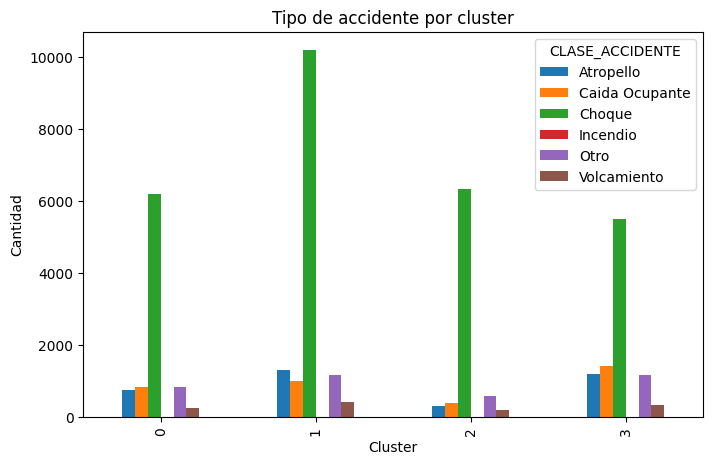

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tabla.plot(kind='bar', figsize=(8,5))
plt.title("Tipo de accidente por cluster")
plt.ylabel("Cantidad")
plt.xlabel("Cluster")
plt.show()

Filtramos tambien por tipo de accidente para ver si hubo muertos o no.

In [ ]:
pd.crosstab(
    [datos['cluster'], datos['CLASE_ACCIDENTE']],
    datos['Gravedad Incidente']
)[['Con muertos']]



Gravedad Incidente       Con muertos
cluster CLASE_ACCIDENTE             
0       Atropello                 20
        Caida Ocupante             2
        Choque                    19
        Incendio                   0
        Otro                       2
        Volcamiento                0
1       Atropello                 33
        Caida Ocupante             3
        Choque                    29
        Incendio                   0
        Otro                       1
        Volcamiento                1
2       Atropello                  7
        Caida Ocupante             0
        Choque                    20
        Incendio                   0
        Otro                       2
        Volcamiento                0
3       Atropello                 25
        Caida Ocupante             1
        Choque                    19
        Otro                       0
        Volcamiento                0

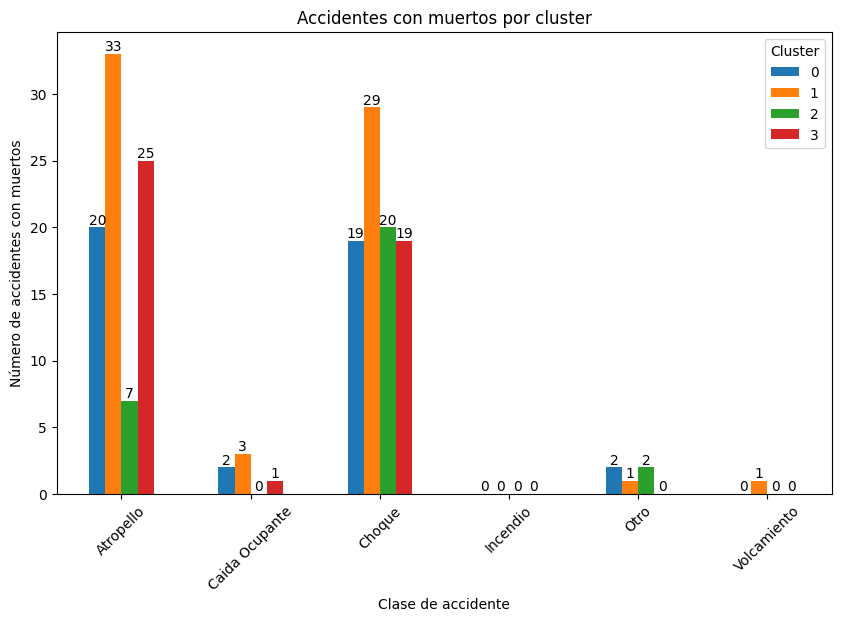

In [ ]:
# Crear gráfico
ax = tabla_plot.plot(kind='bar', figsize=(10,6))

plt.title('Accidentes con muertos por cluster')
plt.xlabel('Clase de accidente')
plt.ylabel('Número de accidentes con muertos')
plt.legend(title='Cluster')
plt.xticks(rotation=45)

# Agregar valores encima de cada barra
for container in ax.containers:
    ax.bar_label(container)

plt.show()

Los accidentes con muertos se concentran principalmente en atropellos y choques en todos los clusters. En particular, el cluster 1 presenta la mayor cantidad de fallecidos, especialmente en atropellos (33) y choques (29), lo que sugiere que este grupo está asociado a accidentes de mayor gravedad.

Filtramos para ver los accidentes por tipo de via

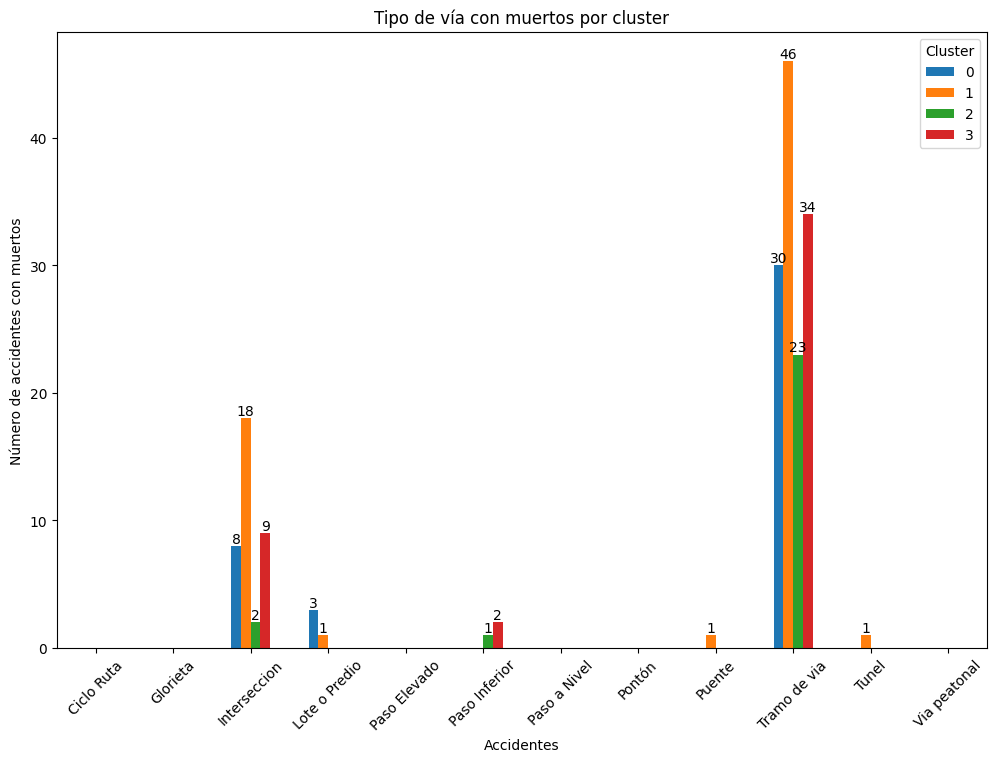

In [ ]:
tabla_diseño = pd.crosstab(
    [datos['cluster'], datos['Diseño']],
    datos['Gravedad Incidente']
)[['Con muertos']]

# Reorganizar la tabla para graficar
tabla_plot2 = tabla_diseño.reset_index().pivot(
    index='Diseño',
    columns='cluster',
    values='Con muertos'
)

ax = tabla_plot2.plot(kind='bar', figsize=(12,8))

plt.title('Tipo de vía con muertos por cluster')
plt.xlabel('Accidentes')
plt.ylabel('Número de accidentes con muertos')
plt.legend(title='Cluster')
plt.xticks(rotation=45)

# Agregar valores pero omitir los ceros
for container in ax.containers:
    labels = [int(v) if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels)

plt.show()

In [ ]:
tabla2 = pd.crosstab(datos['cluster'], datos['Diseño'])
print(tabla)

Diseño   Ciclo Ruta  Glorieta  Interseccion  Lote o Predio  Paso Elevado  \
cluster                                                                    
0                32       364          1934           1339            15   
1                45       467          3160           1666           169   
2                28       316          1298            753            91   
3                29       152          1531           2187            25   

Diseño   Paso Inferior  Paso a Nivel  Pontón  Puente  Tramo de via  Tunel  \
cluster                                                                     
0                   17             6       1      18          5086      2   
1                   93            17       1     107          8318      7   
2                   13            13       0      65          5206      1   
3                   35             3       0      26          5594      0   

Diseño   Via peatonal  
cluster                
0                   3  
1       

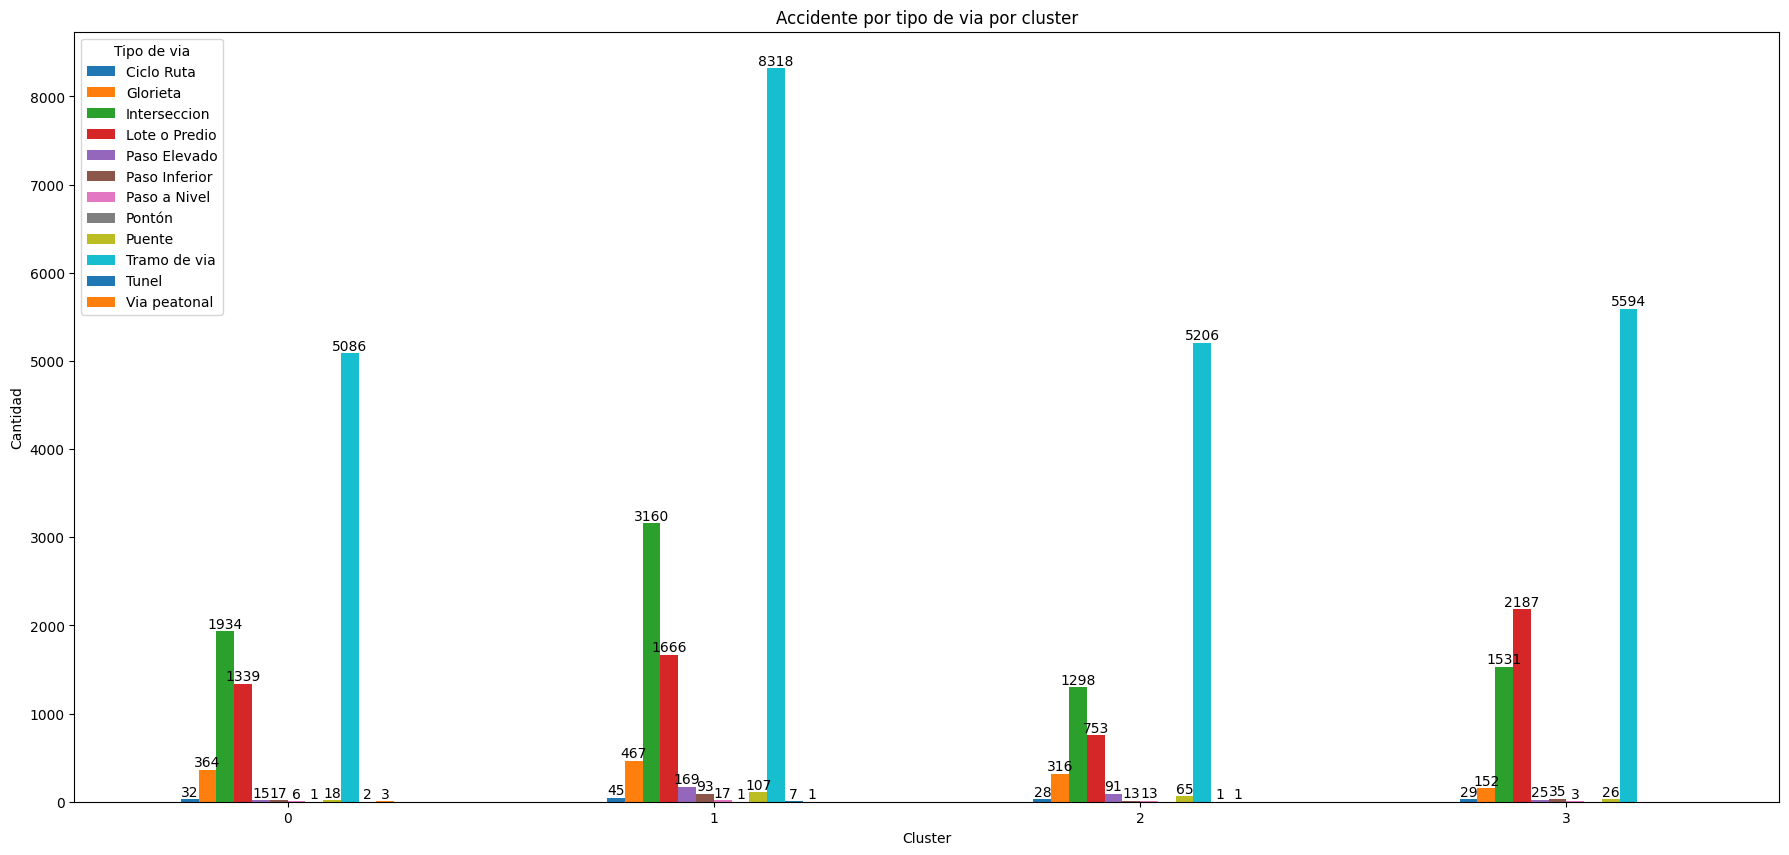

In [ ]:


ax = tabla2.plot(kind='bar', figsize=(22,10))

plt.title("Accidente por tipo de via por cluster")
plt.ylabel("Cantidad")
plt.xlabel("Cluster")
plt.legend(title='Tipo de via')
plt.xticks(rotation=0)

# Agregar valores pero omitir los ceros
for container in ax.containers:
    labels = [int(v) if v > 0 else '' for v in container.datavalues]
    ax.bar_label(container, labels=labels)

plt.show()